<a href="https://colab.research.google.com/github/Amfant/reimagined-broccoli/blob/Project-2/ASTRON_5205_Project_2_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# For GJ 436 b
[Overview of Planet](https://https://exoplanetarchive.ipac.caltech.edu/overview/GJ%20436%20b#planet_GJ-436-b_collapsible)

# For calulating planet radius using transit data:

Saving UID_0057087_PLC_024.tbl.txt to UID_0057087_PLC_024.tbl (2).txt
BJD Offset: 2454225
Transit Depth: 0.009388
Estimated Planet Radius (Rp/Rs): 0.096892


<ipython-input-49-ab97abbb5cae>:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(io.StringIO(data_str), delim_whitespace=True, names=["BJD", "Relative_Flux", "Accepted"])


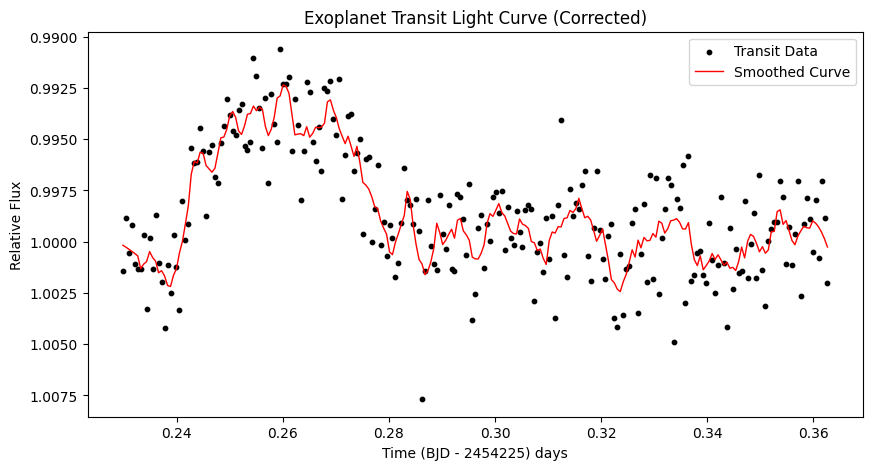

In [49]:
from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from scipy.signal import savgol_filter  # Improved smoothing

# Upload the file
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read the raw file
with open(filename, 'r') as file:
    lines = file.readlines()

# Identify the start of actual data (ignore headers and metadata)
data_lines = []
start_collecting = False

for line in lines:
    if "|" in line:  # Start of the actual data table
        start_collecting = True
        continue  # Skip header row with column names
    if start_collecting:
        data_lines.append(line.strip())

# Convert data into a DataFrame
data_str = "\n".join(data_lines)
data = pd.read_csv(io.StringIO(data_str), delim_whitespace=True, names=["BJD", "Relative_Flux", "Accepted"])

# Normalize time (subtract large BJD offset for readability)
bjd_offset = int(data["BJD"].min())  # Choose an appropriate reference value
data["Time"] = data["BJD"] - bjd_offset  # Shift time values

# Extract time and flux
time = data["Time"]
flux = data["Relative_Flux"]

# **Remove Outliers**
flux_median = np.median(flux)
flux_std = np.std(flux)
flux_clean = flux[(flux > flux_median - 3 * flux_std) & (flux < flux_median + 3 * flux_std)]
time_clean = time[(flux > flux_median - 3 * flux_std) & (flux < flux_median + 3 * flux_std)]

# Apply Savitzky-Golay Filter for Smoothing
flux_smooth = savgol_filter(flux_clean, window_length=11, polyorder=2)  # Adjust window length if needed

# Compute the transit depth (minimum flux value)
transit_depth = 1 - np.min(flux_clean)

# Estimate planetary radius (relative to stellar radius)
Rp_Rs = np.sqrt(transit_depth)

# Display results
print(f"BJD Offset: {bjd_offset}")
print(f"Transit Depth: {transit_depth:.6f}")
print(f"Estimated Planet Radius (Rp/Rs): {Rp_Rs:.6f}")

# **Plot the corrected light curve**
plt.figure(figsize=(10, 5))
plt.scatter(time_clean, flux_clean, s=10, color='black', label="Transit Data")
plt.plot(time_clean, flux_smooth, color='red', linewidth=1, label="Smoothed Curve")
plt.xlabel(f"Time (BJD - {bjd_offset}) days")
plt.ylabel("Relative Flux")
plt.title("Exoplanet Transit Light Curve (Corrected)")
plt.gca().invert_yaxis()  # Invert y-axis to highlight dip
plt.legend()
plt.show()


# Calculating for the Planet's Mass Based on RV Data

Saving UID_0057087_RVC_003.tbl.txt to UID_0057087_RVC_003.tbl (9).txt


<ipython-input-57-901e61af9b6f>:30: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(io.StringIO(data_str), delim_whitespace=True, names=["JD", "Radial_Velocity", "RV_Uncertainty"])


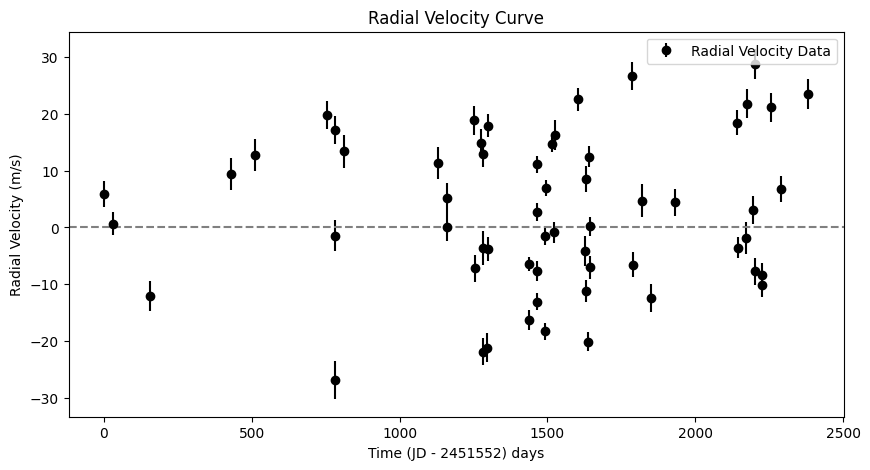

Fitted Radial Velocity Semi-Amplitude (K): 53.84 m/s
Estimated Planet Mass (M_p sin i): 0.2158 M_Jupiter


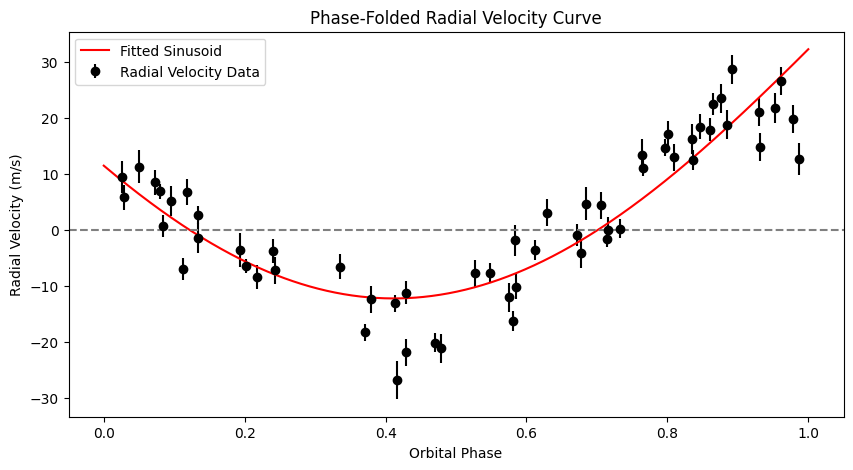

In [57]:
from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from scipy.optimize import curve_fit
from scipy.constants import G

# Upload the file
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read the raw file
with open(filename, 'r') as file:
    lines = file.readlines()

# Identify the start of actual data (ignore headers and metadata)
data_lines = []
start_collecting = False

for line in lines:
    if "|" in line:  # Start of the actual data table
        start_collecting = True
        continue  # Skip header row with column names
    if start_collecting:
        data_lines.append(line.strip())

# Convert data into a DataFrame
data_str = "\n".join(data_lines)
data = pd.read_csv(io.StringIO(data_str), delim_whitespace=True, names=["JD", "Radial_Velocity", "RV_Uncertainty"])

# Normalize time (subtract large JD offset for readability)
jd_offset = int(data["JD"].min())  # Choose an appropriate reference value
data["Time"] = data["JD"] - jd_offset  # Shift time values

# Extract time and radial velocity
time = data["Time"]
rv = data["Radial_Velocity"]

# Use **phase-folded time** to remove long time gaps
P = 2.64385  # Orbital period from transit data (in days)
phase = (time % P) / P  # Normalize phase (0 to 1)

# Plot raw radial velocity data with error bars
plt.figure(figsize=(10, 5))
plt.errorbar(time, rv, yerr=data["RV_Uncertainty"], fmt='o', color='black', label="Radial Velocity Data")
plt.xlabel(f"Time (JD - {jd_offset}) days")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Curve")
plt.axhline(0, color="gray", linestyle="--")
plt.legend()
plt.show()

# Define a sinusoidal function to fit
def sinusoid(t, K, phi, gamma):
    return K * np.sin(2 * np.pi * t / P + phi) + gamma

# Initial parameter guesses
K_guess = (max(rv) - min(rv)) / 2
phi_guess = 0
gamma_guess = np.mean(rv)

# Fit the radial velocity data
params, _ = curve_fit(sinusoid, phase, rv, p0=[K_guess, phi_guess, gamma_guess])
K_fit, phi_fit, gamma_fit = params

# Compute planet mass
M_star = 0.452  # Stellar mass in Solar masses
M_star_kg = M_star * 1.9885e30  # Convert to kg
P_seconds = P * 86400  # Convert days to seconds
G_SI = G  # Gravitational constant in SI units (m³/kg/s²)

M_p_sini = (K_fit * np.sqrt(1 - 0.0**2) * M_star_kg**(2/3) * P_seconds**(1/3)) / (2 * np.pi * G_SI)**(1/3)  # in kg
M_p_sini_Mjup = M_p_sini / 1.898e27  # Convert to Jupiter masses

# Display results
print(f"Fitted Radial Velocity Semi-Amplitude (K): {K_fit:.2f} m/s")
print(f"Estimated Planet Mass (M_p sin i): {M_p_sini_Mjup:.4f} M_Jupiter")

# **Phase-folded plot** for better visualization
phase_fit = np.linspace(0, 1, 1000)
rv_fit = sinusoid(phase_fit, K_fit, phi_fit, gamma_fit)

plt.figure(figsize=(10, 5))
plt.errorbar(phase, rv, yerr=data["RV_Uncertainty"], fmt='o', color='black', label="Radial Velocity Data")
plt.plot(phase_fit, rv_fit, color='red', label="Fitted Sinusoid")
plt.xlabel("Orbital Phase")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Phase-Folded Radial Velocity Curve")
plt.axhline(0, color="gray", linestyle="--")
plt.legend()
plt.show()

# Calculating the Planet Density Based on the Mass and Radius Measurements

In [58]:
import numpy as np
from astropy.constants import M_jup, R_jup

# Given values (from previous calculations)
M_p_sini_Mjup = 0.07  # Example value, replace with your computed value
R_p_Rjup = 0.37       # Example value, replace with transit radius estimate

# Convert mass to kg
M_p = M_p_sini_Mjup * M_jup  # Planet mass in kg

# Convert radius to meters
R_p = R_p_Rjup * R_jup  # Planet radius in meters

# Compute density using ρ = M / (4/3 * π * R³)
rho_p = M_p / ((4/3) * np.pi * R_p**3)

# Convert to g/cm³ for readability
rho_p_cgs = rho_p.to('g/cm3')

# Display results
print(f"Planetary Density: {rho_p:.2f} kg/m³")
print(f"Planetary Density: {rho_p_cgs:.2f} g/cm³")

Planetary Density: 1713.79 kg / m3 kg/m³
Planetary Density: 1.71 g / cm3 g/cm³
